## CS 896 – Data Science Capstone  
### Surface Water and Drinking Water Contaminants  
### Team 10 

**Project goal:** Analyze contaminant patterns in Kansas drinking water and surface water data, identify important contaminants, and evaluate whether surface water contamination can be linked to community drinking water systems.


### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Loading the Drinking Water Dataset

In this step, we load the original CCR drinking water dataset. This dataset contains contaminant names, reported values, units, MCL values, years, and source-system information.

In [2]:
drinking_file = "combined_ccrs_long.csv"

df_raw = pd.read_csv(drinking_file)

print("Original drinking water dataset shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.info())

Original drinking water dataset shape: (16106, 10)


,source,Contaminant,Collection.Date,Highest.Value,Range..low.high.,Unit,MCL,MCLG,Typical.Source,Year
0,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,ARSENIC,1/10/2018,1.1,1.1,ppb,10,0,Erosion of natural deposits,2019
1,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,ATRAZINE,8/20/2018,0.74,0.74,ppb,3,3,Runoff from herbicide used on row crops,2019
2,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,BARIUM,1/10/2018,0.12,0.12,ppm,2,2,Discharge from metal refineries,2019
3,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,CHROMIUM,1/10/2018,5.2,5.2,ppb,100,100,Discharge from steel and pulp mills,2019
4,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,FLUORIDE,1/10/2018,0.35,0.35,ppm,4,4,Natural deposits; Water additive which promote...,2019


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16106 entries, 0 to 16105
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   source            16106 non-null  object
 1   Contaminant       16105 non-null  object
 2   Collection.Date   16101 non-null  object
 3   Highest.Value     16101 non-null  object
 4   Range..low.high.  16099 non-null  object
 5   Unit              16101 non-null  object
 6   MCL               16100 non-null  object
 7   MCLG              16082 non-null  object
 8   Typical.Source    16025 non-null  object
 9   Year              16106 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 1.2+ MB


None

### Initial Data Review

Before cleaning, we check column names, missing values, duplicate records, and the different units used in the dataset.

In [3]:
print("Column names:")
print(df_raw.columns.tolist())

print("\nMissing values:")
display(df_raw.isna().sum())

print("\nDuplicate rows:")
print(df_raw.duplicated().sum())

print("\nUnit values:")
display(df_raw["Unit"].value_counts(dropna=False))

print("\nTop contaminants before cleaning:")
display(df_raw["Contaminant"].value_counts().head(15))

Column names:
['source', 'Contaminant', 'Collection.Date', 'Highest.Value', 'Range..low.high.', 'Unit', 'MCL', 'MCLG', 'Typical.Source', 'Year']

Missing values:


source               0
Contaminant          1
Collection.Date      5
Highest.Value        5
Range..low.high.     7
Unit                 5
MCL                  6
MCLG                24
Typical.Source      81
Year                 0
dtype: int64


Duplicate rows:
0

Unit values:


Unit
ppm        8237
ppb        7508
PCI/L       240
MG/L         89
µg/l          8
5             6
NaN           5
pCi/l         4
ppt           3
15            2
Unit          1
UMHO/CM       1
LANG          1
PH            1
Name: count, dtype: int64


Top contaminants before cleaning:


Contaminant
BARIUM                           3086
FLUORIDE                         2627
SELENIUM                         2408
NITRATE                          2406
CHROMIUM                         2057
ARSENIC                          2008
ATRAZINE                          846
COMBINED RADIUM (-226 & -228)     141
METHOXYCHLOR                       75
GROSS ALPHA, INCL. RADON & U       48
NITRATE-NITRITE                    42
XYLENES, TOTAL                     41
RADIUM-228                         28
CARBON TETRACHLORIDE               28
2,4-D                              27
Name: count, dtype: int64

### Clean Drinking Water Dataset

The drinking water data has values in different units such as ppb, ppm, and mg/L. Since ppb is easier to compare across contaminants, all concentration values are converted to ppb.

In [4]:
df = df_raw.copy()

# Clean column names without changing the meaning of the original data
df.columns = df.columns.str.strip()

# Standardize contaminant names and unit values
df["Contaminant"] = df["Contaminant"].astype(str).str.strip().str.upper()
df["Unit"] = df["Unit"].astype(str).str.strip().str.lower()

# Convert date column
df["Collection.Date"] = pd.to_datetime(df["Collection.Date"], errors="coerce")

# Use Year column if available, otherwise extract from date
if "Year" in df.columns:
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
else:
    df["Year"] = df["Collection.Date"].dt.year

df["Year_num"] = df["Year"]

# Function to handle values like <0.5, ND, and regular numbers
def clean_numeric_value(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).strip()
    
    if value.upper() in ["ND", "N/D", "NON-DETECT", "NON DETECT", "NA", "NAN", ""]:
        return np.nan
    
    # For values like <0.5, we keep the numeric part as 0.5
    match = re.search(r"[-+]?\d*\.?\d+", value)
    if match:
        return float(match.group())
    
    return np.nan

df["Highest.Value"] = df["Highest.Value"].apply(clean_numeric_value)
df["MCL"] = df["MCL"].apply(clean_numeric_value)

# Convert concentration values to ppb
def convert_to_ppb(value, unit):
    if pd.isna(value):
        return np.nan
    
    unit = str(unit).lower().strip()
    
    if unit in ["ppb", "ug/l", "µg/l", "ug/liter", "micrograms/liter"]:
        return value
    elif unit in ["ppm", "mg/l", "mg/liter", "milligrams/liter"]:
        return value * 1000
    else:
        return value

df["Highest_ppb"] = df.apply(lambda row: convert_to_ppb(row["Highest.Value"], row["Unit"]), axis=1)
df["MCL_ppb"] = df.apply(lambda row: convert_to_ppb(row["MCL"], row["Unit"]), axis=1)

# Remove duplicate rows
before_duplicates = df.shape[0]
df = df.drop_duplicates()
after_duplicates = df.shape[0]

print("Rows before duplicate removal:", before_duplicates)
print("Rows after duplicate removal:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

# Keep rows needed for analysis
df = df.dropna(subset=["Contaminant", "Highest_ppb", "Year"])

print("Cleaned drinking water dataset shape:", df.shape)
display(df.head())

Rows before duplicate removal: 16106
Rows after duplicate removal: 16106
Duplicates removed: 0
Cleaned drinking water dataset shape: (16100, 13)


,source,Contaminant,Collection.Date,Highest.Value,Range..low.high.,Unit,MCL,MCLG,Typical.Source,Year,Year_num,Highest_ppb,MCL_ppb
0,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,ARSENIC,2018-01-10,1.10,1.1,ppb,10.0,0,Erosion of natural deposits,2019,2019,1.10,10.0
1,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,ATRAZINE,2018-08-20,0.74,0.74,ppb,3.0,3,Runoff from herbicide used on row crops,2019,2019,0.74,3.0
2,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,BARIUM,2018-01-10,0.12,0.12,ppm,2.0,2,Discharge from metal refineries,2019,2019,120.00,2000.0
3,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,CHROMIUM,2018-01-10,5.20,5.2,ppb,100.0,100,Discharge from steel and pulp mills,2019,2019,5.20,100.0
4,ABBYVILLE_CITY_OF-KS2015512.docxx.docx,FLUORIDE,2018-01-10,0.35,0.35,ppm,4.0,4,Natural deposits; Water additive which promote...,2019,2019,350.00,4000.0


### Create Exceedance and Outlier Variables

This step creates two important project variables:

- `Exceed_MCL`: identifies whether a reported contaminant value is above its regulatory limit.
- `Outlier_Flag`: identifies unusually high or low values using the IQR method within each contaminant.

In [5]:
# MCL exceedance flag
df["Exceed_MCL"] = np.where(
    (df["MCL_ppb"].notna()) & (df["Highest_ppb"] > df["MCL_ppb"]),
    1,
    0
)

# IQR outlier flag by contaminant
df["Outlier_Flag"] = 0

for contaminant in df["Contaminant"].unique():
    temp = df[df["Contaminant"] == contaminant]
    
    q1 = temp["Highest_ppb"].quantile(0.25)
    q3 = temp["Highest_ppb"].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    df.loc[
        (df["Contaminant"] == contaminant) &
        ((df["Highest_ppb"] < lower_bound) | (df["Highest_ppb"] > upper_bound)),
        "Outlier_Flag"
    ] = 1

print("Feature engineering completed.")
display(df[["Contaminant", "Highest_ppb", "MCL_ppb", "Exceed_MCL", "Outlier_Flag"]].head())

Feature engineering completed.


,Contaminant,Highest_ppb,MCL_ppb,Exceed_MCL,Outlier_Flag
0,ARSENIC,1.10,10.0,0,0
1,ATRAZINE,0.74,3.0,0,0
2,BARIUM,120.00,2000.0,0,0
3,CHROMIUM,5.20,100.0,0,0
4,FLUORIDE,350.00,4000.0,0,0


### Drinking Water EDA
Here we identify the most frequently reported contaminants. This helps decide which contaminants have enough observations for trend analysis.

Contaminant
BARIUM                           3086
FLUORIDE                         2627
SELENIUM                         2408
NITRATE                          2406
CHROMIUM                         2057
ARSENIC                          2008
ATRAZINE                          846
COMBINED RADIUM (-226 & -228)     141
METHOXYCHLOR                       75
GROSS ALPHA, INCL. RADON & U       48
Name: count, dtype: int64

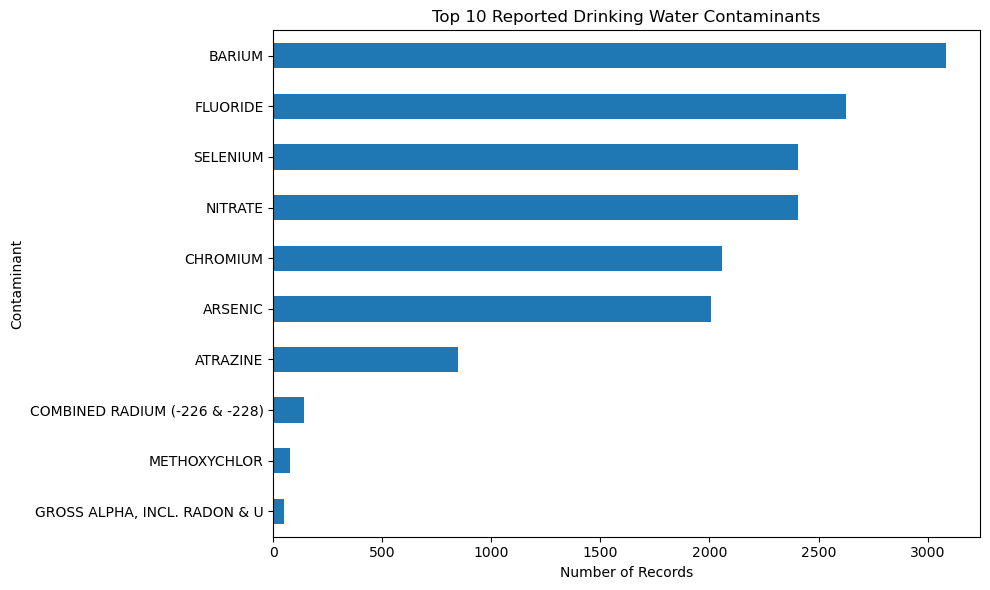

In [6]:
top_contaminants = df["Contaminant"].value_counts().head(10)

display(top_contaminants)

plt.figure(figsize=(10, 6))
top_contaminants.sort_values().plot(kind="barh")
plt.title("Top 10 Reported Drinking Water Contaminants")
plt.xlabel("Number of Records")
plt.ylabel("Contaminant")
plt.tight_layout()
plt.savefig("top_contaminants.png", dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The frequency distribution shows that Barium, Fluoride, Selenium, Nitrate, and Chromium are the most commonly reported contaminants in the dataset. These contaminants appear significantly more often than the others, which indicates that they have sufficient data available for further analysis.

This is important because contaminants with a higher number of observations provide more reliable patterns for trend analysis, exceedance evaluation, and comparison. Based on this result, the top five contaminants were selected for deeper analysis in the next steps.

### Top 5 Contaminant Trend Analysis

The top five contaminants are analyzed over time. This is more useful than combining all contaminants because each contaminant behaves differently.

,Year,Contaminant,Highest_ppb
0,2019,BARIUM,126.389486
1,2019,CHROMIUM,3.004412
2,2019,FLUORIDE,512.740516
3,2019,NITRATE,2840.525687
4,2019,SELENIUM,7.341345


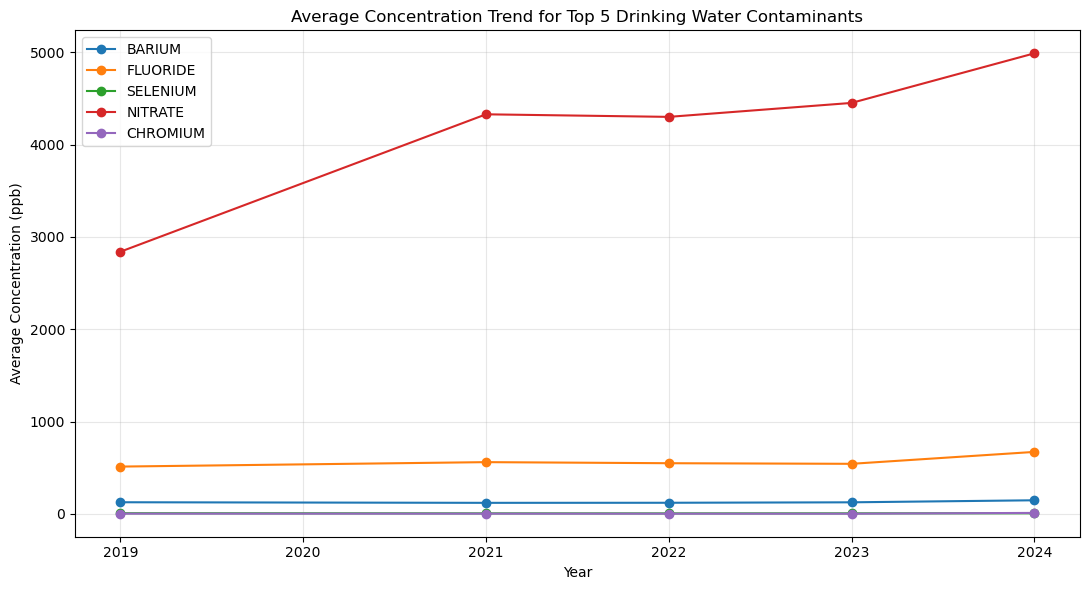

In [7]:
top5 = df["Contaminant"].value_counts().head(5).index.tolist()
df_top5 = df[df["Contaminant"].isin(top5)].copy()

trend_top5 = (
    df_top5
    .groupby(["Year", "Contaminant"])["Highest_ppb"]
    .mean()
    .reset_index()
)

display(trend_top5.head())

plt.figure(figsize=(11, 6))

for contaminant in top5:
    temp = trend_top5[trend_top5["Contaminant"] == contaminant]
    plt.plot(temp["Year"], temp["Highest_ppb"], marker="o", label=contaminant)

plt.title("Average Concentration Trend for Top 5 Drinking Water Contaminants")
plt.xlabel("Year")
plt.ylabel("Average Concentration (ppb)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("top5_trend.png", dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The trend plot shows clear differences in concentration levels across the top five contaminants. Nitrate stands out with significantly higher concentration values compared to all other contaminants throughout the years.

From the plot, nitrate increases from around 2800 ppb in 2019 to nearly 5000 ppb in 2024, with some fluctuations in between. In contrast, contaminants such as Barium, Fluoride, Selenium, and Chromium remain relatively stable with only minor variations over time.

This indicates that most contaminants do not show strong temporal changes, while nitrate behaves differently and may require closer attention in drinking water monitoring.

### Nitrate Trend in Drinking Water

Nitrate is analyzed separately because it showed much higher concentration levels than the other common contaminants.

,Year,Highest_ppb
0,2019,2816.745006
1,2021,4266.399345
2,2022,4249.061372
3,2023,4364.860759
4,2024,4945.987261


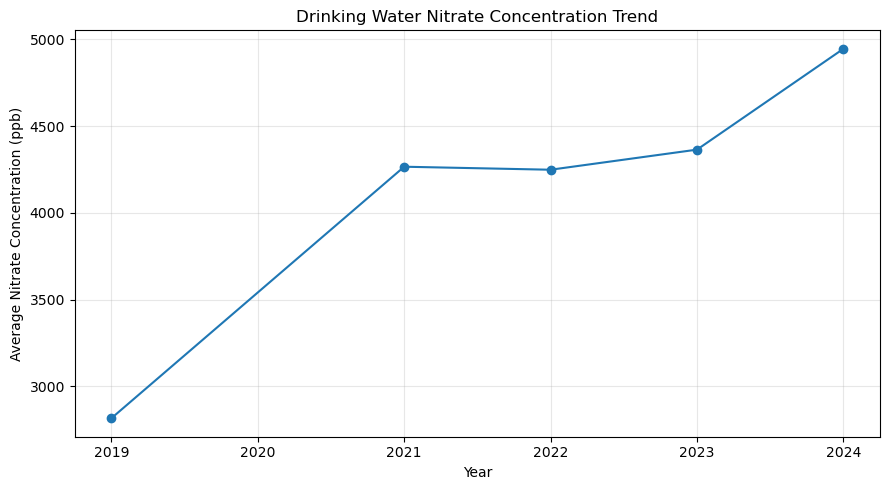

In [8]:
nitrate_dw = df[df["Contaminant"].str.contains("NITRATE", case=False, na=False)].copy()

nitrate_trend_dw = (
    nitrate_dw
    .groupby("Year")["Highest_ppb"]
    .mean()
    .reset_index()
)

display(nitrate_trend_dw)

plt.figure(figsize=(9, 5))
plt.plot(nitrate_trend_dw["Year"], nitrate_trend_dw["Highest_ppb"], marker="o")
plt.title("Drinking Water Nitrate Concentration Trend")
plt.xlabel("Year")
plt.ylabel("Average Nitrate Concentration (ppb)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("drinking_nitrate_trend.png", dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The nitrate trend confirms that nitrate levels are consistently higher than other contaminants and show noticeable variation across years. The average concentration increases from approximately 2800 ppb in 2019 to around 4900 ppb in 2024.

Although there are some fluctuations between years, the overall pattern suggests an increasing trend. This makes nitrate an important contaminant to monitor, as its concentration levels are much higher compared to the other commonly reported contaminants in the dataset.

### Regression Attempt

A simple linear regression was tested using year as the predictor and concentration as the response. This was done to check whether contaminant concentration changes over time when all contaminants are combined.

Regression Results
------------------
Slope: 1.2953637350762421
Intercept: -1848.949767097257
R-squared: 2.999772937828382e-07
p-value: 0.944599448436071


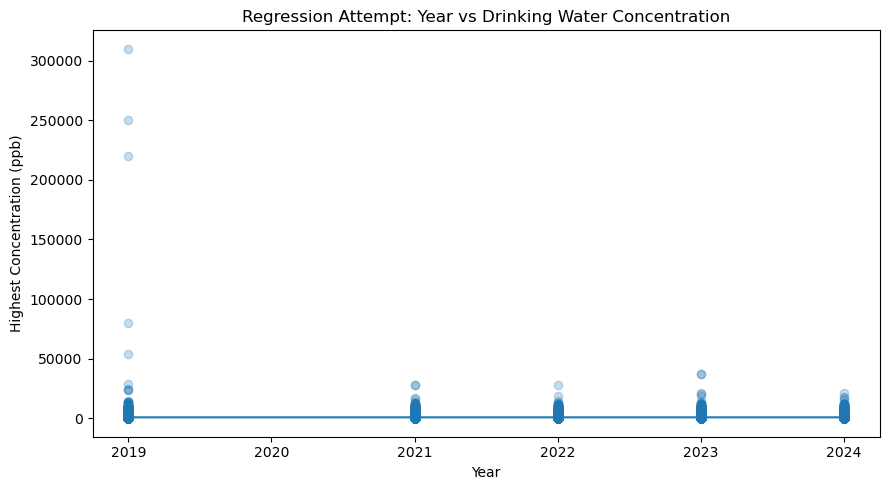

In [9]:
model_df = df[["Year_num", "Highest_ppb"]].dropna().copy()

X = model_df[["Year_num"]]
y = model_df["Highest_ppb"]

linear_model = LinearRegression()
linear_model.fit(X, y)

y_pred = linear_model.predict(X)
r2 = r2_score(y, y_pred)

slope, intercept, r_value, p_value, std_err = stats.linregress(
    model_df["Year_num"],
    model_df["Highest_ppb"]
)

print("Regression Results")
print("------------------")
print("Slope:", slope)
print("Intercept:", intercept)
print("R-squared:", r2)
print("p-value:", p_value)

plt.figure(figsize=(9, 5))
plt.scatter(model_df["Year_num"], model_df["Highest_ppb"], alpha=0.25)
plt.plot(model_df["Year_num"], y_pred)
plt.title("Regression Attempt: Year vs Drinking Water Concentration")
plt.xlabel("Year")
plt.ylabel("Highest Concentration (ppb)")
plt.tight_layout()
plt.savefig("regression_plot.png", dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The regression results show an extremely low R-squared value (approximately 0), along with a very high p-value (around 0.94). This indicates that there is no statistically significant linear relationship between year and contaminant concentration when all contaminants are combined.

This result suggests that combining all contaminants into a single model is not meaningful because each contaminant has a different concentration scale, source, and behavior. As a result, the variation in the dataset is driven more by differences between contaminants than by changes over time.

This confirms that contaminant-specific analysis is more appropriate than aggregated modeling.

### Log-transformed regression

Log Regression R-squared: 0.0008303839355717768


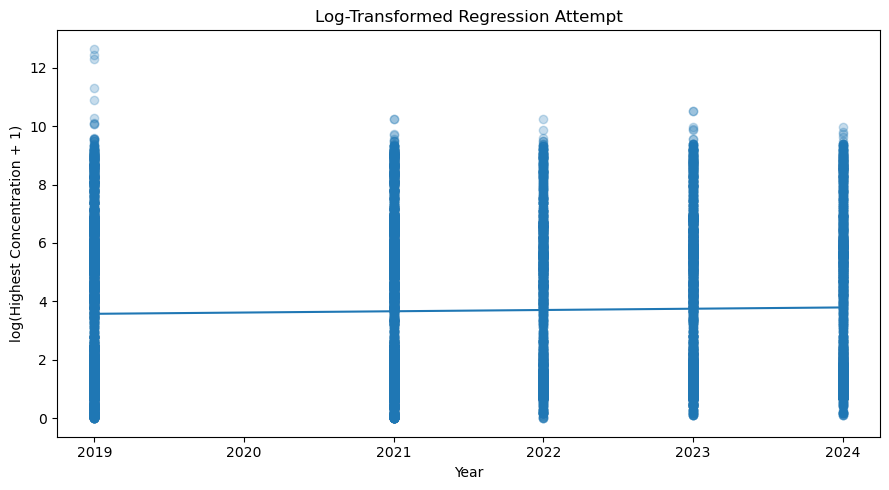

In [10]:
log_df = df[["Year_num", "Highest_ppb"]].dropna().copy()
log_df = log_df[log_df["Highest_ppb"] > 0]
log_df["Log_Highest_ppb"] = np.log1p(log_df["Highest_ppb"])

X_log = log_df[["Year_num"]]
y_log = log_df["Log_Highest_ppb"]

log_model = LinearRegression()
log_model.fit(X_log, y_log)

log_pred = log_model.predict(X_log)
log_r2 = r2_score(y_log, log_pred)

print("Log Regression R-squared:", log_r2)

plt.figure(figsize=(9, 5))
plt.scatter(log_df["Year_num"], log_df["Log_Highest_ppb"], alpha=0.25)
plt.plot(log_df["Year_num"], log_pred)
plt.title("Log-Transformed Regression Attempt")
plt.xlabel("Year")
plt.ylabel("log(Highest Concentration + 1)")
plt.tight_layout()
plt.savefig("regression_plot.png", dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The log-transformed regression slightly improves the visualization of the data, but the R-squared value remains very low. This indicates that even after transformation, year is not a strong predictor of contaminant concentration.

This further supports the conclusion that simple linear models are not sufficient to explain the behavior of all contaminants combined. More meaningful insights can be obtained by analyzing contaminants individually rather than using aggregated models.

### Exceedance Analysis

This step checks which contaminants exceeded their MCL values most often.

,Contaminant,Total_Records,Exceedance_Count,Exceedance_Rate,Mean_ppb,Median_ppb
25,ETHYLENE DIBROMIDE,1,1,1.000000,68.000000,68.00
29,GROSS BETA PARTICLE ACTIVITY,4,4,1.000000,6.600000,6.60
56,TOXAPHENE,1,1,1.000000,21.000000,21.00
20,CORROSIVITY,1,1,1.000000,0.400000,0.40
31,HEPTACHLOR EPOXIDE,1,1,1.000000,210.000000,210.00
34,METHOXYCHLOR,75,33,0.440000,440.114933,0.25
55,TOLUENE,10,2,0.200000,1402.288000,1.00
45,RADIUM-226,27,4,0.148148,1.237037,1.00
46,RADIUM-228,28,3,0.107143,0.992857,0.80
8,ATRAZINE,846,53,0.062648,0.972453,0.60


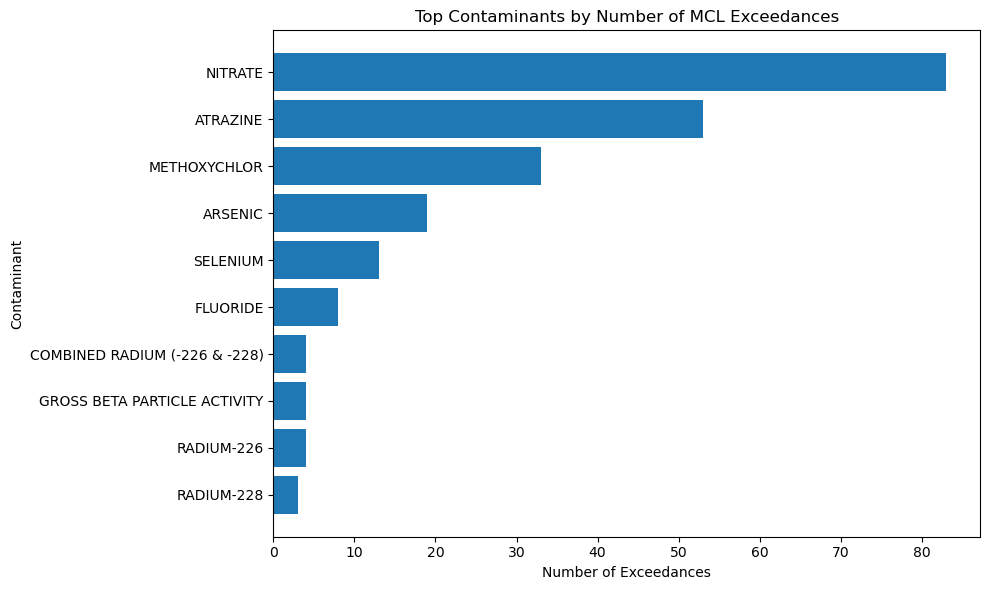

In [11]:
exceedance_summary = (
    df.groupby("Contaminant")
    .agg(
        Total_Records=("Contaminant", "count"),
        Exceedance_Count=("Exceed_MCL", "sum"),
        Exceedance_Rate=("Exceed_MCL", "mean"),
        Mean_ppb=("Highest_ppb", "mean"),
        Median_ppb=("Highest_ppb", "median")
    )
    .reset_index()
    .sort_values("Exceedance_Rate", ascending=False)
)

display(exceedance_summary.head(15))

top_exceedance_counts = exceedance_summary.sort_values("Exceedance_Count", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_exceedance_counts["Contaminant"], top_exceedance_counts["Exceedance_Count"])
plt.title("Top Contaminants by Number of MCL Exceedances")
plt.xlabel("Number of Exceedances")
plt.ylabel("Contaminant")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("exceedance_chart.png", dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

The exceedance analysis shows that some contaminants have very high exceedance rates, but these are often based on a very small number of observations. For example, contaminants such as Ethylene Dibromide and Toxaphene show high exceedance rates but have very limited data points.

In contrast, contaminants like Nitrate and Atrazine have moderate exceedance rates but a much larger number of observations. For example, nitrate has an exceedance rate of approximately 3.4% with over 2400 records, making it more relevant for overall analysis.

This indicates that both exceedance rate and sample size should be considered together when evaluating contaminant risk.

### Outlier Analysis

Outliers were not removed because they may represent important extreme contaminant measurements. Instead, they were flagged and summarized.

In [12]:
outlier_summary = (
    df.groupby("Contaminant")
    .agg(
        Total_Records=("Contaminant", "count"),
        Outlier_Count=("Outlier_Flag", "sum"),
        Outlier_Rate=("Outlier_Flag", "mean")
    )
    .reset_index()
    .sort_values("Outlier_Rate", ascending=False)
)

display(outlier_summary.head(15))

,Contaminant,Total_Records,Outlier_Count,Outlier_Rate
45,RADIUM-226,27,10,0.370370
55,TOLUENE,10,2,0.200000
46,RADIUM-228,28,5,0.178571
24,ETHYLBENZENE,12,1,0.083333
13,CARBON TETRACHLORIDE,28,2,0.071429
8,ATRAZINE,846,54,0.063830
9,BARIUM,3086,182,0.058976
47,SELENIUM,2408,130,0.053987
15,CHROMIUM,2057,106,0.051531
26,FLUORIDE,2627,115,0.043776


### Interpretation

The outlier analysis shows that some contaminants have a high proportion of extreme values. For example, Radium-226 and Radium-228 have relatively high outlier rates compared to other contaminants.

This suggests that these contaminants exhibit higher variability and may occasionally reach extreme concentration levels. On the other hand, common contaminants such as Barium, Selenium, and Chromium show moderate outlier rates, indicating more stable behavior.

Outliers are important because they highlight unusual conditions that may not be visible through average values alone.

### Final Drinking Water Summary Table

This summary combines frequency, concentration, exceedance, and outlier information for each contaminant.

In [13]:
final_drinking_summary = (
    df.groupby("Contaminant")
    .agg(
        Total_Records=("Contaminant", "count"),
        Mean_ppb=("Highest_ppb", "mean"),
        Median_ppb=("Highest_ppb", "median"),
        Max_ppb=("Highest_ppb", "max"),
        Exceedance_Count=("Exceed_MCL", "sum"),
        Exceedance_Rate=("Exceed_MCL", "mean"),
        Outlier_Count=("Outlier_Flag", "sum"),
        Outlier_Rate=("Outlier_Flag", "mean")
    )
    .reset_index()
    .sort_values("Total_Records", ascending=False)
)

display(final_drinking_summary.head(20))

final_drinking_summary.to_csv("final_drinking_water_summary.csv", index=False)
df.to_csv("cleaned_drinking_water_final.csv", index=False)

print("Drinking water cleaned file and summary table saved.")

,Contaminant,Total_Records,Mean_ppb,Median_ppb,Max_ppb,Exceedance_Count,Exceedance_Rate,Outlier_Count,Outlier_Rate
9,BARIUM,3086,126.751750,90.00,850.0,0,0.000000,182,0.058976
26,FLUORIDE,2627,557.503236,360.00,28000.0,8,0.003045,115,0.043776
47,SELENIUM,2408,6.541030,3.80,1300.0,13,0.005399,130,0.053987
37,NITRATE,2406,3912.938487,3200.00,37000.0,83,0.034497,22,0.009144
15,CHROMIUM,2057,3.927467,2.20,2600.0,1,0.000486,106,0.051531
7,ARSENIC,2008,3.070618,2.20,110.0,19,0.009462,67,0.033367
8,ATRAZINE,846,0.972453,0.60,10.0,53,0.062648,54,0.063830
17,COMBINED RADIUM (-226 & -228),141,1.491986,1.00,7.0,4,0.028369,6,0.042553
34,METHOXYCHLOR,75,440.114933,0.25,1000.0,33,0.440000,0,0.000000
28,"GROSS ALPHA, INCL. RADON & U",48,4.570833,3.50,20.0,3,0.062500,2,0.041667


Drinking water cleaned file and summary table saved.


### Interpretation

The final summary table combines multiple aspects of contaminant behavior, including frequency, concentration levels, exceedance rates, and outlier rates.

From this summary, nitrate clearly stands out with the highest average concentration (around 3900 ppb), while other contaminants remain significantly lower. Barium and Fluoride also have relatively high average values but do not reach the same level as nitrate.

This confirms that nitrate is the most prominent contaminant in terms of concentration, while other contaminants may still be important based on exceedance or variability.